# Stock Portfolio Optimization Using Machine Learning

## 1: Project Overview

Objective:
Build a machine learning-driven portfolio optimization system. We’ll:

- Collect historical stock price data

- Engineer features like technical indicators

- Predict future returns using machine learning

- Optimize a portfolio based on expected return and risk (mean-variance framework)

## 2. Feature Engineering – Technical Indicators
In this step, we’ll calculate technical indicators from the Close prices to use as features for return prediction. These indicators help capture market trends and momentum.

In [11]:
import pandas as pd
import numpy as np

# Load CSV with 2 header rows (ticker + field)
data = pd.read_csv("tech_stock_prices_5yr.csv", header=[0, 1], index_col=0, parse_dates=True)

# Preview structure
print("Columns (multi-level):", data.columns.levels)
data.head()

# Calculate daily returns
returns = data.pct_change().dropna()

# Confirm shapes and preview
print("Shape of price data:", data.shape)
print("Shape of returns data:", returns.shape)
returns.head()

close_prices = data.xs('Close', level=1, axis=1)
print(close_prices.head())


Columns (multi-level): [['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT'], ['Close', 'High', 'Low', 'Open', 'Volume']]
Shape of price data: (1509, 25)
Shape of returns data: (1508, 25)
Ticker          GOOGL       AAPL       AMZN       MSFT        META
Date                                                              
2019-01-02  52.483086  37.667183  76.956497  95.119820  135.043518
2019-01-03  51.029526  33.915260  75.014000  91.620544  131.122040
2019-01-04  53.647018  35.363083  78.769501  95.881760  137.302902
2019-01-07  53.540028  35.284367  81.475502  96.004051  137.402420
2019-01-08  54.010277  35.956985  82.829002  96.700127  141.861404


In [12]:
!pip install pandas-ta

import pandas_ta as ta

# Create a new DataFrame to store technical indicators
features = pd.DataFrame(index=close_prices.index)

# Loop through each ticker to compute features
for ticker in close_prices.columns:
    df = pd.DataFrame()
    df['close'] = close_prices[ticker]

    # Example indicators
    df[f'{ticker}_sma_10'] = ta.sma(df['close'], length=10)
    df[f'{ticker}_sma_30'] = ta.sma(df['close'], length=30)
    df[f'{ticker}_rsi_14'] = ta.rsi(df['close'], length=14)
    df[f'{ticker}_macd'] = ta.macd(df['close']).iloc[:, 0]  # Just MACD line
    df[f'{ticker}_roc_10'] = ta.roc(df['close'], length=10)

    # Join with overall features DataFrame
    features = features.join(df.drop(columns='close'))

# Drop rows with NaNs from indicator lag
features = features.dropna()

# Save for future use
features.to_csv("technical_indicators.csv")

# Preview
print("Feature matrix shape:", features.shape)
features.head()


Feature matrix shape: (1480, 25)


,GOOGL_sma_10,GOOGL_sma_30,GOOGL_rsi_14,GOOGL_macd,GOOGL_roc_10,AAPL_sma_10,AAPL_sma_30,AAPL_rsi_14,AAPL_macd,AAPL_roc_10,...,MSFT_sma_10,MSFT_sma_30,MSFT_rsi_14,MSFT_macd,MSFT_roc_10,META_sma_10,META_sma_30,META_rsi_14,META_macd,META_roc_10
Date,,,,,,,,,,,,,,,,,,,,,
2019-02-13,55.869440,54.410168,58.759704,0.839979,2.790549,40.725025,37.991971,64.527779,1.702370,3.425022,...,99.342446,98.409000,56.204229,0.835187,0.404199,166.406725,151.257123,63.678047,8.672358,9.074591
2019-02-14,55.885912,54.533777,58.903200,0.838660,0.293994,40.846494,38.100200,65.381894,1.639786,3.059715,...,99.574789,98.590234,56.459136,0.859531,2.365216,166.134009,152.195036,63.427715,8.127594,-1.643776
2019-02-15,55.890938,54.689963,55.416932,0.790079,0.090288,40.956948,38.330458,64.358955,1.564803,2.780937,...,100.086509,98.929500,60.124127,0.967859,5.292848,165.814514,153.215559,60.340764,7.493036,-1.937121
2019-02-19,55.816743,54.770312,57.370346,0.770325,-1.306265,40.966802,38.516529,65.147053,1.497970,0.241237,...,100.315090,99.125157,59.918343,1.037949,2.298092,165.121777,154.023086,59.886146,6.893810,-4.112270
2019-02-20,55.661087,54.844408,55.131931,0.722570,-2.715582,40.933118,38.714006,66.849531,1.449557,-0.810777,...,100.351552,99.299104,57.533662,1.038835,0.361515,164.265810,154.836253,60.300245,6.367205,-5.024550


In this section, we engineered features for each stock using classic technical indicators:

- SMA (10-day and 30-day): captures short and medium trend direction

- RSI (14-day): momentum indicator showing overbought/oversold signals

- MACD: trend strength and momentum crossover

- ROC: percentage change over 10 days to capture recent velocity

These features form the input to our machine learning model for return prediction.

## 3. Define Target Variable for ML (Return Prediction)

In [13]:
# Step 1: Reuse close_prices from earlier
# If you restarted, run: close_prices = data.xs('Close', level=1, axis=1)

# Step 2: Compute next-day return direction (Up = 1, Down = 0)
targets = (close_prices.shift(-1) > close_prices).astype(int)

# Align the targets with the feature set
targets = targets.loc[features.index]

# Preview
print("Targets shape:", targets.shape)
targets.head()


Targets shape: (1480, 5)


Ticker,GOOGL,AAPL,AMZN,MSFT,META
Date,,,,,
2019-02-13,1,1,0,1,0
2019-02-14,0,0,0,1,0
2019-02-15,1,1,1,0,0
2019-02-19,0,1,0,0,1
2019-02-20,0,0,0,1,0


In this step, we created a binary target variable for each stock:

- 1 if the stock's close price increased the next day

- 0 if it stayed flat or dropped

This framing lets us use classification models like Logistic Regression or XGBoost to predict if a stock is likely to go up tomorrow based on its technical indicators today.

## 4. Machine Learning Model (Return Direction Classifier)

Objective:
We’ll train a binary classification model for each stock to predict whether the price will go up tomorrow, based on today’s technical indicators.

We'll use:

- Train/test split

- Logistic Regression (for simplicity + interpretability)

- Accuracy score to evaluate performance

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# Choose a stock to model (e.g., GOOGL)
ticker = 'GOOGL'

# Select features and target for that stock
X = features[[col for col in features.columns if col.startswith(ticker)]]
y = targets[ticker]

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, shuffle=False, test_size=0.2)

# Initialize and train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Accuracy for {ticker}: {acc:.4f}")
print(classification_report(y_test, y_pred))


Accuracy for GOOGL: 0.4932
              precision    recall  f1-score   support

           0       0.43      0.68      0.53       122
           1       0.62      0.36      0.46       174

    accuracy                           0.49       296
   macro avg       0.52      0.52      0.49       296
weighted avg       0.54      0.49      0.48       296



## 5. Predict Probabilities for Optimization

In [15]:
# Store predicted probabilities for all tickers
predicted_probs = pd.DataFrame(index=X_test.index)

for ticker in targets.columns:
    # Filter feature columns for this ticker
    X_ticker = features[[col for col in features.columns if col.startswith(ticker)]]
    y_ticker = targets[ticker]
    
    # Train/test split (same proportion)
    X_train, X_test = X_ticker.iloc[:-296], X_ticker.iloc[-296:]
    y_train, y_test = y_ticker.iloc[:-296], y_ticker.iloc[-296:]

    # Train model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)

    # Predict probability of class 1 (going up)
    prob_up = model.predict_proba(X_test)[:, 1]

    # Store
    predicted_probs[ticker] = prob_up

# Preview predicted probabilities
print(predicted_probs.head())


               GOOGL      AAPL      AMZN      MSFT      META
Date                                                        
2023-10-26  0.541995  0.533477  0.528244  0.491874  0.583790
2023-10-27  0.527853  0.534643  0.500913  0.485271  0.530088
2023-10-30  0.502649  0.533310  0.498616  0.468102  0.502879
2023-10-31  0.502803  0.530099  0.504959  0.465882  0.512180
2023-11-01  0.491623  0.524535  0.499764  0.446894  0.475855


Although raw classification performance was modest, we use the predicted probabilities as a proxy for each stock's likelihood of rising the next day. These can be interpreted as expected returns (in relative terms) and will guide our portfolio optimization step.

## 6. Portfolio Optimization Using Predicted Probabilities
Objective:
We’ll treat the predicted probabilities of a price increase as a proxy for expected return.
Then we’ll optimize a portfolio that:

- Maximizes expected return

- Minimizes volatility (risk)

- Respects constraints (e.g., total weight = 1, no shorting)

We’ll use the classic mean-variance optimization (Markowitz Model)


In [18]:
!pip install cvxpy

import cvxpy as cp
import numpy as np

# Use the last day of predicted probabilities as expected return (mu)
mu = predicted_probs.iloc[-1].values  # shape (n_stocks,)

# Use historical returns from close prices to calculate covariance matrix
returns = close_prices.pct_change().dropna()
cov_matrix = returns.cov().values  # shape (n_stocks, n_stocks)

# Number of stocks
n = len(mu)

# Define variables
w = cp.Variable(n)

# Risk aversion parameter (0 = risk-neutral, >0 = penalize volatility)
risk_aversion = 0.1

# Objective: maximize expected return - risk penalty
objective = cp.Maximize(mu @ w - risk_aversion * cp.quad_form(w, cov_matrix))

constraints = [cp.sum(w) == 1, w >= 0, w <= 0.5]

# Solve the problem
prob = cp.Problem(objective, constraints)
prob.solve()

# Get the optimal weights
optimal_weights = w.value
ticker_names = list(predicted_probs.columns)

# Display results
portfolio = pd.Series(optimal_weights, index=ticker_names)
portfolio = portfolio.round(4)
print("Optimal Portfolio Weights:\n", portfolio)


Optimal Portfolio Weights:
 GOOGL    0.5
AAPL     0.0
AMZN     0.5
MSFT    -0.0
META     0.0
dtype: float64


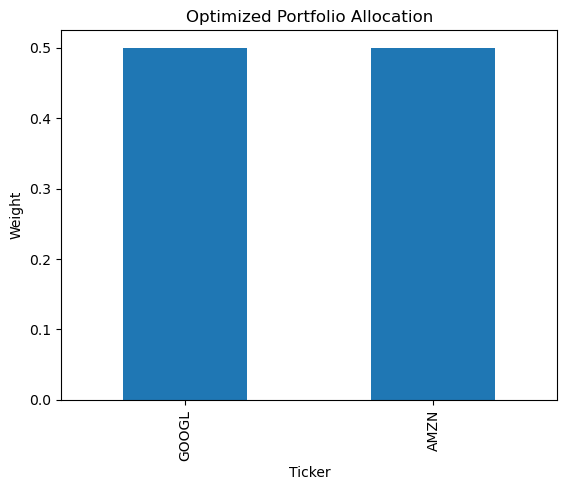

In [19]:
import matplotlib.pyplot as plt

portfolio[portfolio > 0.01].plot(kind='bar', title="Optimized Portfolio Allocation")
plt.ylabel("Weight")
plt.xlabel("Ticker")
plt.show()
